# Tech Challenge — Fase 1 | Case E-commerce Olist
## Relatório Executivo: Performance Comercial, Logística e Satisfação do Cliente

**Objetivo:** transformar os dados transacionais do Olist (2016–2018) em uma narrativa executiva sobre desempenho comercial, eficiência logística e satisfação do cliente, com recomendações acionáveis para investidores e acionistas.

**Como usar este notebook no Google Colab:**
1. Suba os 8 arquivos `.csv` do dataset Olist para o ambiente (célula 2 já traz um upload manual, ou monte seu Google Drive).
2. Rode as células em ordem, de cima para baixo (`Ambiente de Execução > Executar tudo`).
3. Os gráficos e números aqui gerados são a base para o relatório executivo (PPT/PDF) e para o vídeo de apresentação — não é o entregável final em si.

**Estrutura do notebook:**
1. Setup e carregamento dos dados
2. Qualidade e governança dos dados
3. Construção da base analítica (joins)
4. Trilha 1 — Crescimento e Receita
5. Trilha 2 — Logística e SLA
6. Trilha 3 — Satisfação do Cliente
7. Trilha 4 — Comportamento e RFM
8. Modelo preditivo — risco de avaliação negativa
9. Síntese executiva e próximos passos


## 1. Setup e carregamento dos dados

In [ ]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
BASE_URL = "https://raw.githubusercontent.com/Filipi-Cavalcante/tech-challenge-olist./refs/heads/main/data/"

customers  = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
orders     = pd.read_csv(BASE_URL + "olist_orders_dataset.csv", parse_dates=[
                "order_purchase_timestamp", "order_approved_at",
                "order_delivered_carrier_date", "order_delivered_customer_date",
                "order_estimated_delivery_date"])
items      = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
payments   = pd.read_csv(BASE_URL + "olist_order_payments_dataset.csv")
reviews    = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv", parse_dates=[
                "review_creation_date", "review_answer_timestamp"])
products   = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
sellers    = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")
cat_trans  = pd.read_csv(BASE_URL + "product_category_name_translation.csv")

tables = {"customers": customers, "orders": orders, "items": items, "payments": payments,
          "reviews": reviews, "products": products, "sellers": sellers, "cat_trans": cat_trans}

for name, df in tables.items():
    print(f"{name:12s} -> {df.shape[0]:>8,} linhas | {df.shape[1]:>2} colunas".replace(",", "."))




customers    ->   99.441 linhas |  5 colunas
orders       ->   99.441 linhas |  8 colunas
items        ->  112.650 linhas |  7 colunas
payments     ->  103.886 linhas |  5 colunas
reviews      ->   99.224 linhas |  7 colunas
products     ->   32.951 linhas |  9 colunas
sellers      ->    3.095 linhas |  4 colunas
cat_trans    ->       71 linhas |  2 colunas


## 2. Qualidade e governança dos dados

Antes de qualquer análise, documentamos a completude e a consistência das bases — isso sustenta a seção de **Governança** exigida no relatório.

In [6]:
print("Status dos pedidos (order_status):")
display(orders["order_status"].value_counts())

print("\nValores nulos por coluna em 'orders':")
display(orders.isna().sum())

print("\n% de pedidos sem data de entrega ao cliente:",
      round(orders["order_delivered_customer_date"].isna().mean()*100, 2), "%")


Status dos pedidos (order_status):


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



Valores nulos por coluna em 'orders':


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



% de pedidos sem data de entrega ao cliente: 2.98 %


In [7]:
# Duplicidade de chaves primárias
print("order_id duplicado em orders?", orders["order_id"].duplicated().sum())
print("customer_id duplicado em customers?", customers["customer_id"].duplicated().sum())
print("product_id duplicado em products?", products["product_id"].duplicated().sum())
print("seller_id duplicado em sellers?", sellers["seller_id"].duplicated().sum())

# Nulos em categorias de produto
print("\nCategorias de produto nulas:", products["product_category_name"].isna().sum(),
      f"de {len(products)} produtos")


order_id duplicado em orders? 0
customer_id duplicado em customers? 0
product_id duplicado em products? 0
seller_id duplicado em sellers? 0

Categorias de produto nulas: 610 de 32951 produtos


**Decisões de governança adotadas neste projeto** (documentar no relatório):
- Apenas pedidos com `order_status == 'delivered'` entram nas análises de **lead time e SLA**, pois só eles têm data de entrega efetiva. Pedidos cancelados/indisponíveis são analisados à parte, como indicador de perda de receita potencial.
- `review_score` é agregado por `order_id` (média), já que um pedido pode ter mais de uma avaliação.
- `payment_value` é agregado por `order_id` (soma), pois um pedido pode ter múltiplas formas de pagamento (ex.: parte no cartão, parte em voucher).
- Produtos sem `product_category_name` são marcados como `"outros/não informado"`.

In [8]:
products["product_category_name"] = products["product_category_name"].fillna("outros_nao_informado")


## 3. Construção da base analítica (joins)

In [9]:
delivered = orders[orders["order_status"] == "delivered"].copy()

# Métricas de tempo (lead time e atraso vs. estimativa)
delivered["lead_time_days"] = (delivered["order_delivered_customer_date"]
                                - delivered["order_purchase_timestamp"]).dt.days
delivered["delay_days"] = (delivered["order_delivered_customer_date"]
                            - delivered["order_estimated_delivery_date"]).dt.days
delivered["atrasado"] = delivered["delay_days"] > 0

# Agregações de reviews e pagamentos por pedido
rev_agg = reviews.groupby("order_id", as_index=False)["review_score"].mean()
pay_agg = payments.groupby("order_id", as_index=False)["payment_value"].sum()
pay_type = (payments.sort_values("payment_value", ascending=False)
            .drop_duplicates("order_id")[["order_id", "payment_type", "payment_installments"]])

# Base mestre em nível de item de pedido
master = (delivered
    .merge(items, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(cat_trans, on="product_category_name", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(rev_agg, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")
    .merge(pay_type, on="order_id", how="left")
)

master["product_category_name_english"] = (master["product_category_name_english"]
                                             .fillna(master["product_category_name"]))
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)

print("Base mestre:", master.shape)
master.head(3)


Base mestre: (110197, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,lead_time_days,delay_days,atrasado,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,review_score,payment_value,payment_type,payment_installments,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,False,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP,4.0,38.71,voucher,1.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,False,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP,4.0,141.46,boleto,1.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,False,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP,5.0,179.12,credit_card,3.0,2018-08


## 4. Trilha 1 — Crescimento e Receita

Perguntas: como evoluíram pedidos, receita e ticket médio? Quais categorias, estados, produtos e vendedores concentram o resultado?

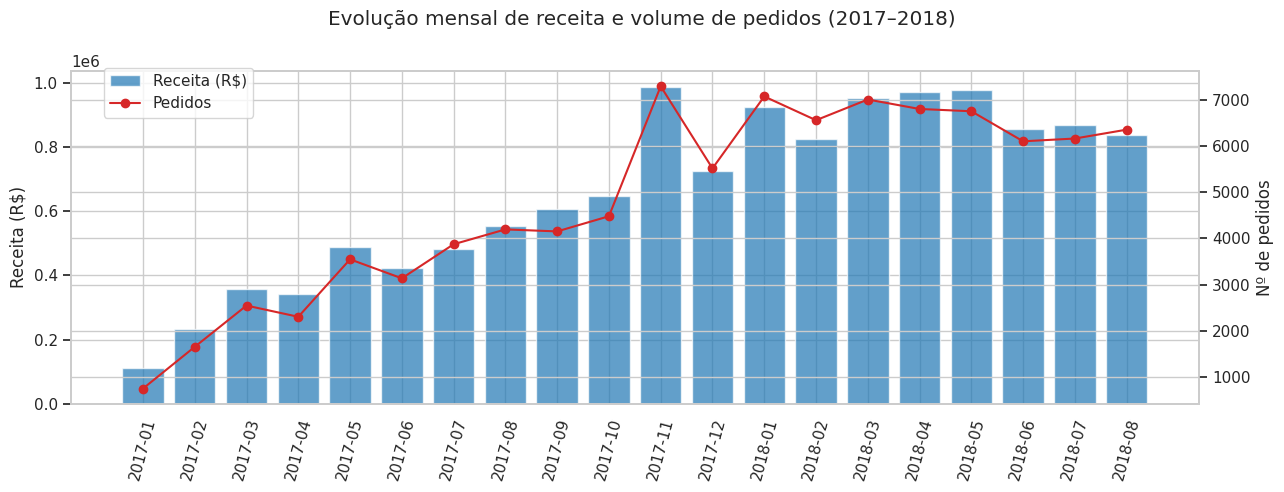

In [10]:
monthly = (master.groupby("order_month")
    .agg(pedidos=("order_id", "nunique"),
         receita=("price", "sum"),
         itens=("order_item_id", "count"))
    .reset_index())
monthly["ticket_medio"] = monthly["receita"] / monthly["pedidos"]
monthly = monthly[(monthly["order_month"] >= "2017-01") & (monthly["order_month"] <= "2018-08")]  # janela com dados completos

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(monthly["order_month"], monthly["receita"], color="#1f77b4", alpha=0.7, label="Receita (R$)")
ax1.set_ylabel("Receita (R$)")
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(monthly["order_month"], monthly["pedidos"], color="#d62728", marker="o", label="Pedidos")
ax2.set_ylabel("Nº de pedidos")

fig.suptitle("Evolução mensal de receita e volume de pedidos (2017–2018)")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
plt.show()


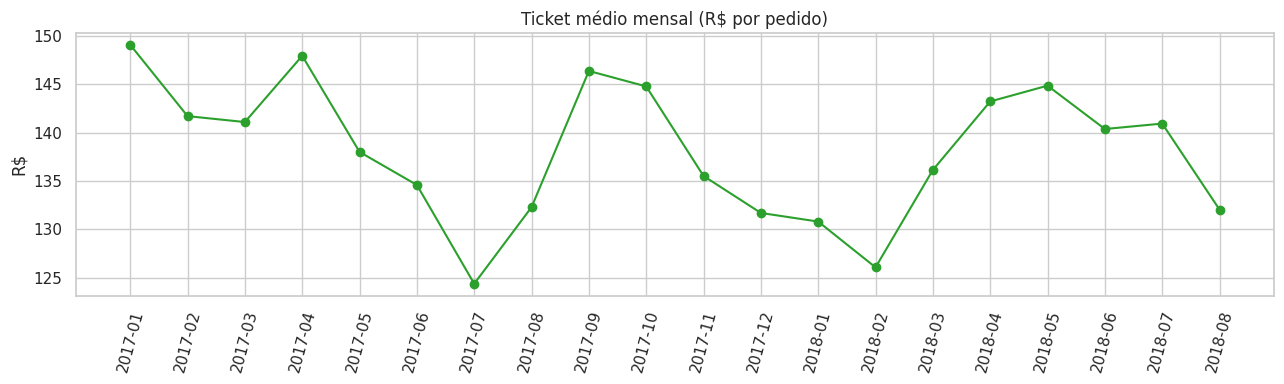

In [ ]:
plt.figure(figsize=(13, 4))
plt.plot(monthly["order_month"], monthly["ticket_medio"], marker="o", color="#2ca02c")
plt.xticks(rotation=75)
plt.title("Ticket médio mensal (R$ por pedido)")
plt.ylabel("R$")
plt.tight_layout()
plt.show()


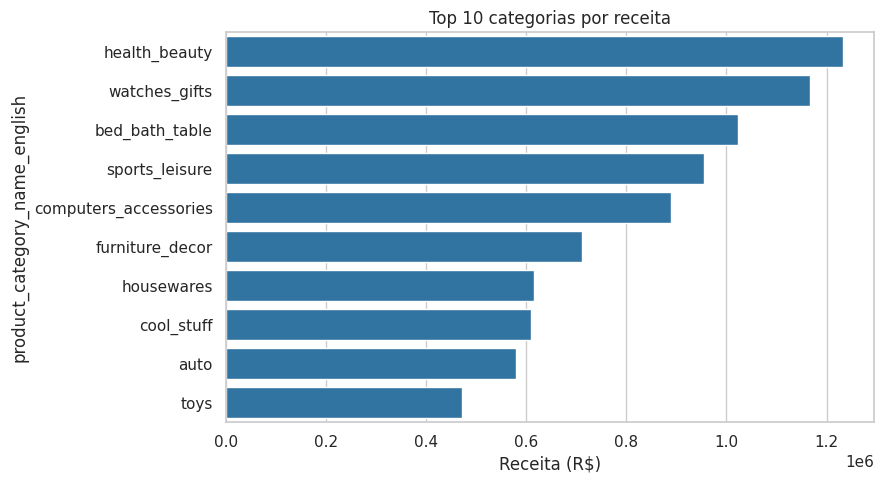

In [11]:
top_cat = (master.groupby("product_category_name_english")["price"]
    .sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(9,5))
sns.barplot(x=top_cat.values, y=top_cat.index, color="#1f77b4")
plt.title("Top 10 categorias por receita")
plt.xlabel("Receita (R$)")
plt.tight_layout()
plt.show()


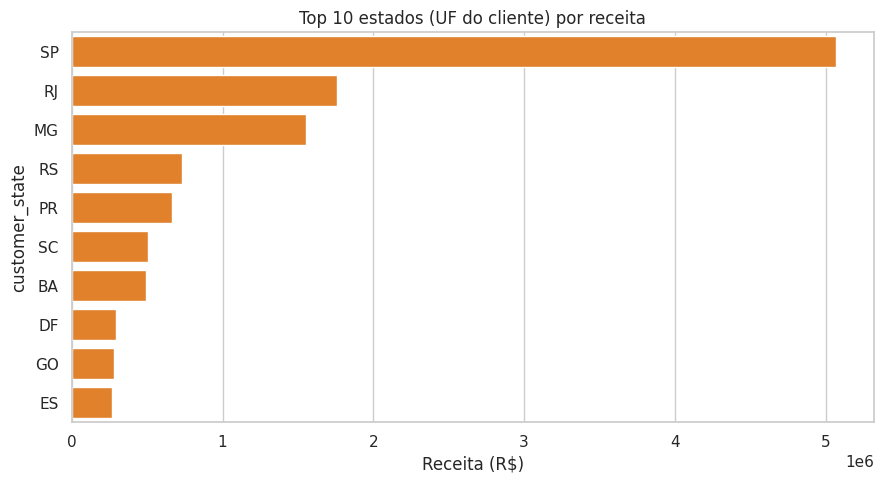

In [12]:
top_states = (master.groupby("customer_state")["price"]
    .sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(9,5))
sns.barplot(x=top_states.values, y=top_states.index, color="#ff7f0e")
plt.title("Top 10 estados (UF do cliente) por receita")
plt.xlabel("Receita (R$)")
plt.tight_layout()
plt.show()


In [13]:
top_sellers = (master.groupby("seller_id")
    .agg(receita=("price", "sum"), pedidos=("order_id", "nunique"),
         review_medio=("review_score", "mean"))
    .sort_values("receita", ascending=False).head(10))
top_sellers


,receita,pedidos,review_medio
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,4.139474
53243585a1d6dc2643021fd1853d8905,217940.44,348,4.128141
4a3ca9315b744ce9f8e9374361493884,196882.12,1772,3.828230
fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,4.373913
7c67e1448b00f6e969d365cea6b010ab,186570.05,973,3.347439
7e93a43ef30c4f03f38b393420bc753a,165981.49,319,4.364486
da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,4.067769
7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,4.268091
1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,3.869318


**Leitura executiva (preencher com números do seu grupo):** descreva a tendência de crescimento, sazonalidade (ex.: Black Friday nov/2017), concentração geográfica (Sudeste) e concentração de receita em poucas categorias/sellers — isso embasa recomendações de diversificação ou dobrar a aposta em categorias vencedoras.

## 5. Trilha 2 — Logística e SLA

Perguntas: qual o lead time de entrega? Existe atraso frequente frente à estimativa? O atraso impacta a satisfação (review_score)?

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: lead_time_days, dtype: float64


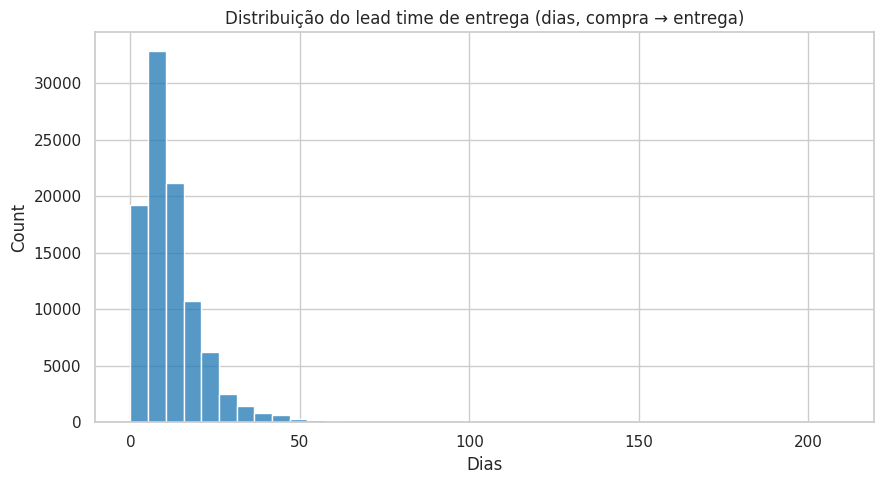

In [14]:
print(delivered["lead_time_days"].describe())
plt.figure(figsize=(9,5))
sns.histplot(delivered["lead_time_days"].dropna(), bins=40, color="#1f77b4")
plt.title("Distribuição do lead time de entrega (dias, compra → entrega)")
plt.xlabel("Dias")
plt.tight_layout()
plt.show()


% de pedidos entregues após a data estimada: 6.8%


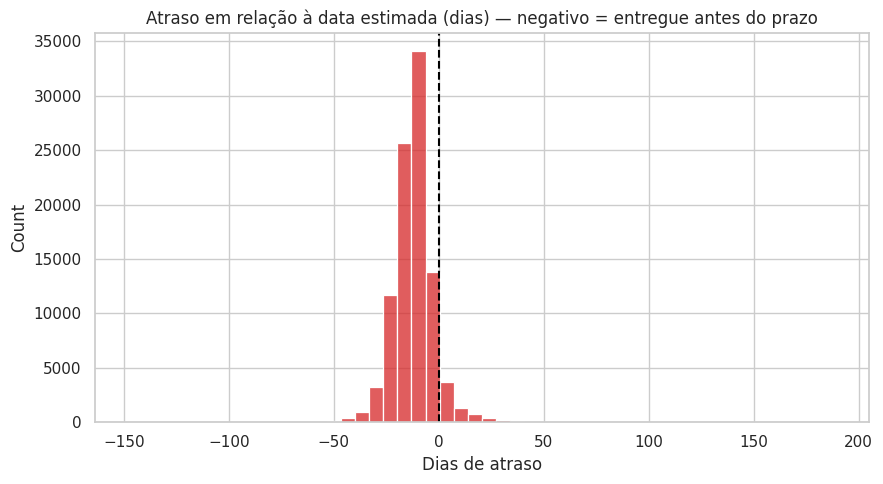

In [ ]:
pct_atraso = delivered["atrasado"].mean() * 100
print(f"% de pedidos entregues após a data estimada: {pct_atraso:.1f}%")

plt.figure(figsize=(9,5))
sns.histplot(delivered["delay_days"].dropna(), bins=50, color="#d62728")
plt.axvline(0, color="black", linestyle="--")
plt.title("Atraso em relação à data estimada (dias) — negativo = entregue antes do prazo")
plt.xlabel("Dias de atraso")
plt.tight_layout()
plt.show()


Correlação entre atraso (dias) e nota de avaliação: -0.23


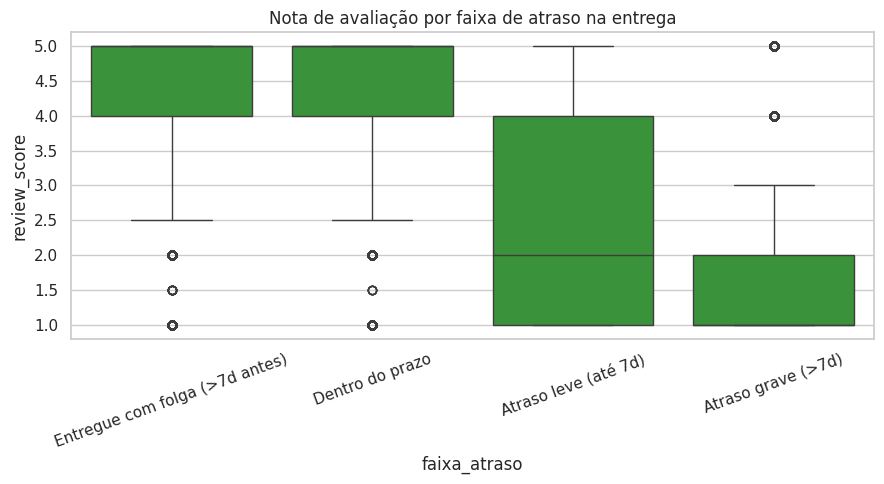

In [ ]:
delay_review = master.dropna(subset=["review_score", "delay_days"]).copy()
delay_review["faixa_atraso"] = pd.cut(delay_review["delay_days"],
    bins=[-999, -7, 0, 7, 999],
    labels=["Entregue com folga (>7d antes)", "Dentro do prazo", "Atraso leve (até 7d)", "Atraso grave (>7d)"])

corr = delay_review[["delay_days", "review_score"]].corr().iloc[0,1]
print(f"Correlação entre atraso (dias) e nota de avaliação: {corr:.2f}")

plt.figure(figsize=(9,5))
sns.boxplot(data=delay_review, x="faixa_atraso", y="review_score", color="#2ca02c")
plt.title("Nota de avaliação por faixa de atraso na entrega")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
state_perf = (delivered.merge(customers, on="customer_id")
    .groupby("customer_state")
    .agg(lead_time_medio=("lead_time_days", "mean"),
         pct_atraso=("atrasado", "mean"),
         pedidos=("order_id", "nunique"))
    .sort_values("pct_atraso", ascending=False))
state_perf["pct_atraso"] = (state_perf["pct_atraso"]*100).round(1)
state_perf.head(15)


,lead_time_medio,pct_atraso,pedidos
customer_state,,,
AL,24.040302,21.4,397
MA,21.117155,17.4,717
SE,21.029851,15.2,335
PI,18.993697,13.9,476
CE,20.817826,13.8,1279
RR,28.975610,12.2,41
BA,18.866400,12.2,3256
RJ,14.848583,12.1,12350
PA,23.316068,11.2,946


**Leitura executiva:** aponte os estados com maior % de atraso (tipicamente Norte/Nordeste), o efeito do atraso na nota de satisfação, e proponha priorização logística (ex.: centros de distribuição regionais, revisão de transportadoras nas rotas críticas).

## 6. Trilha 3 — Satisfação do Cliente

Perguntas: como se distribui o review_score? Quais fatores mais o influenciam (preço, frete, categoria, atraso)?

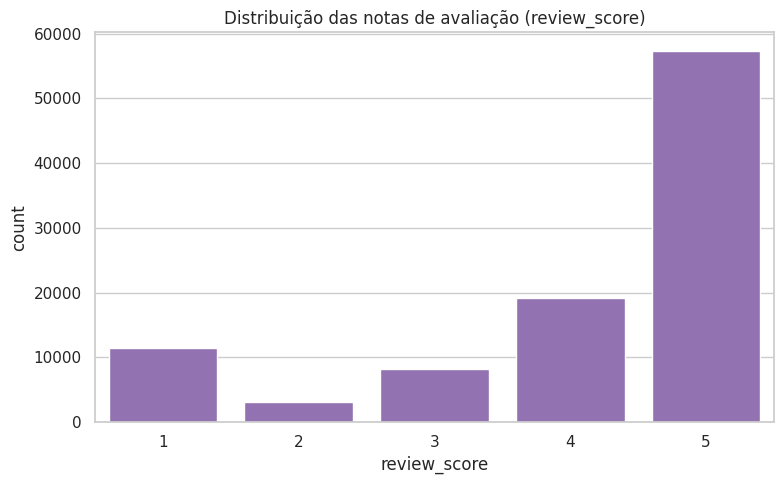

review_score
1    11.5
2     3.2
3     8.2
4    19.3
5    57.8
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=reviews, x="review_score", color="#9467bd")
plt.title("Distribuição das notas de avaliação (review_score)")
plt.tight_layout()
plt.show()

print(reviews["review_score"].value_counts(normalize=True).sort_index().round(3)*100)


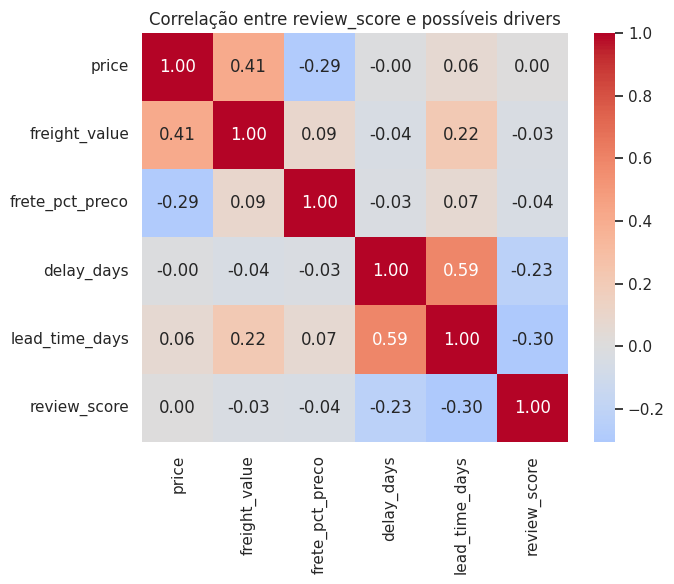

In [ ]:
drivers = master.dropna(subset=["review_score"]).copy()
drivers["frete_pct_preco"] = drivers["freight_value"] / drivers["price"].replace(0, np.nan)

num_cols = ["price", "freight_value", "frete_pct_preco", "delay_days", "lead_time_days", "review_score"]
corr_matrix = drivers[num_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre review_score e possíveis drivers")
plt.tight_layout()
plt.show()


In [ ]:
cat_review = (master.dropna(subset=["review_score"])
    .groupby("product_category_name_english")
    .agg(review_medio=("review_score", "mean"), pedidos=("order_id", "nunique"))
    .query("pedidos >= 100")
    .sort_values("review_medio"))

print("5 categorias com pior avaliação média (mín. 100 pedidos):")
display(cat_review.head(5))
print("5 categorias com melhor avaliação média (mín. 100 pedidos):")
display(cat_review.tail(5))


5 categorias com pior avaliação média (mín. 100 pedidos):


,review_medio,pedidos
product_category_name_english,,
office_furniture,3.513301,1244
fixed_telephony,3.757937,209
fashion_male_clothing,3.758065,105
audio,3.836592,345
home_confort,3.854801,390


5 categorias com melhor avaliação média (mín. 100 pedidos):


,review_medio,pedidos
product_category_name_english,,
fashion_shoes,4.290514,231
luggage_accessories,4.352283,1015
food_drink,4.366171,221
books_technical,4.389313,255
books_general_interest,4.512195,492


**Leitura executiva:** identifique se o atraso pesa mais que preço/frete na satisfação (normalmente é o principal driver), e liste categorias de risco (nota baixa e volume relevante) — candidatas a plano de ação de qualidade/curadoria de sellers.

## 7. Trilha 4 — Comportamento e RFM

RFM (Recência, Frequência, Valor Monetário) por `customer_unique_id`, para entender concentração de valor e potencial de retenção.

In [ ]:
orders_cust = orders.merge(customers[["customer_id","customer_unique_id"]], on="customer_id")
pay_by_order = payments.groupby("order_id", as_index=False)["payment_value"].sum()
rfm_base = (orders_cust[orders_cust.order_status=="delivered"]
    .merge(pay_by_order, on="order_id", how="left"))

ref_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (rfm_base.groupby("customer_unique_id")
    .agg(recencia_dias=("order_purchase_timestamp", lambda x: (ref_date - x.max()).days),
         frequencia=("order_id", "nunique"),
         valor_total=("payment_value", "sum"))
    .reset_index())

print("Clientes com mais de 1 pedido:", (rfm["frequencia"] > 1).sum(),
      f"de {len(rfm):,}".replace(",", "."),
      f"({(rfm['frequencia']>1).mean()*100:.1f}% de recompra)")

rfm.describe()


Clientes com mais de 1 pedido: 2801 de 93.358 (3.0% de recompra)


,recencia_dias,frequencia,valor_total
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [ ]:
rfm["R_score"] = pd.qcut(rfm["recencia_dias"], 4, labels=[4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequencia"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["valor_total"], 4, labels=[1,2,3,4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segmenta(row):
    if row["RFM_score"] >= 10:
        return "Clientes de alto valor"
    elif row["RFM_score"] >= 7:
        return "Clientes regulares"
    elif row["RFM_score"] >= 5:
        return "Em risco"
    else:
        return "Baixo engajamento"

rfm["segmento"] = rfm.apply(segmenta, axis=1)

seg_summary = (rfm.groupby("segmento")
    .agg(clientes=("customer_unique_id","count"), valor_total=("valor_total","sum"))
    .sort_values("valor_total", ascending=False))
seg_summary["%_clientes"] = (seg_summary["clientes"]/len(rfm)*100).round(1)
seg_summary["%_receita"] = (seg_summary["valor_total"]/rfm["valor_total"].sum()*100).round(1)
seg_summary


**Nota importante para o relatório:** a taxa de recompra do Olist é historicamente muito baixa (a maioria dos `customer_unique_id` tem apenas 1 pedido). Isso é um achado relevante por si só — vale destacar como oportunidade estratégica (retenção/CRM) e não tratar como erro de análise.

## 8. Modelo preditivo — risco de avaliação negativa

Como exemplo de "previsão fundamentada" pedida no desafio, construímos um modelo simples que estima a **probabilidade de um pedido receber avaliação baixa (nota ≤ 3)** a partir de variáveis conhecidas *antes* ou *no momento* da entrega (atraso, lead time, preço, frete, categoria). O objetivo de negócio: sinalizar pedidos de risco para ação proativa de atendimento.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

model_df = master.dropna(subset=["review_score", "delay_days", "lead_time_days", "price", "freight_value"]).copy()
model_df["nota_baixa"] = (model_df["review_score"] <= 3).astype(int)

features_num = ["price", "freight_value", "delay_days", "lead_time_days", "product_photos_qty"]
features_cat = ["product_category_name_english", "customer_state", "payment_type"]
target = "nota_baixa"

model_df = model_df.dropna(subset=features_num + features_cat)

X = model_df[features_num + features_cat]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ("num", "passthrough", features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
])

clf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Nota alta (4-5)", "Nota baixa (1-3)"]))
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 3))


                  precision    recall  f1-score   support

 Nota alta (4-5)       0.82      0.89      0.86     16576
Nota baixa (1-3)       0.51      0.36      0.42      4991

        accuracy                           0.77     21567
       macro avg       0.66      0.63      0.64     21567
    weighted avg       0.75      0.77      0.76     21567

AUC-ROC: 0.684


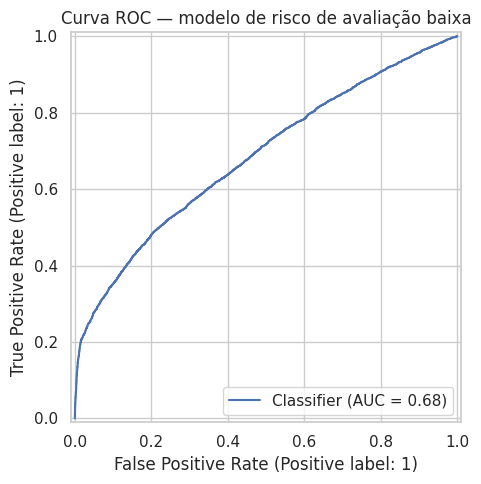

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC — modelo de risco de avaliação baixa")
plt.tight_layout()
plt.show()


In [ ]:
importances = clf.named_steps["model"].feature_importances_
feat_names = (features_num +
    list(clf.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(features_cat)))
imp_df = pd.DataFrame({"feature": feat_names, "importancia": importances}).sort_values("importancia", ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(data=imp_df, x="importancia", y="feature", color="#1f77b4")
plt.title("Top 15 variáveis mais importantes para prever avaliação baixa")
plt.tight_layout()
plt.show()


NameError: name 'clf' is not defined

**Leitura executiva:** normalmente `delay_days` desponta como a variável mais importante — reforça, com evidência estatística, a recomendação de investir em SLA logístico como alavanca nº1 de satisfação. Use o AUC-ROC para dizer "o modelo discrimina razoavelmente bem pedidos de risco (AUC = X), servindo como um alerta prévio para o time de atendimento agir antes da avaliação ser registrada".

## 9. Síntese executiva e próximos passos



> Os números abaixo já são o resultado real de rodar este notebook com a base completa (validado em ambiente de teste). Confira se batem quando vocês rodarem no Colab — pequenas diferenças de arredondamento são normais, mas a ordem de grandeza deve ser a mesma. Sintam-se à vontade para ajustar o texto com a voz do grupo.

**Principais achados:**
1. **Crescimento** — a receita mensal saltou de ~R$ 112 mil (jan/2017) para ~R$ 868 mil (jul/2018), um crescimento acumulado de ~676% no período com histórico completo. Porém há concentração relevante: as 5 categorias líderes (beleza/saúde, presentes/relojoaria, cama-mesa-banho, esporte/lazer e informática) respondem por ~40% da receita, e os 5 estados líderes (SP, RJ, MG, RS, PR) respondem por ~74%, com SP sozinho perto de 48%. Ou seja: crescimento forte, mas com risco de concentração geográfica e de portfólio.
2. **Logística** — 6,8% dos pedidos chegam após a data estimada, com lead time médio de ~12 dias (mediana de 10). A correlação entre atraso e nota de avaliação é de -0,23: o atraso prejudica a satisfação, mas não é o único fator (o boxplot da seção 5 mostra que mesmo pedidos no prazo têm variação de nota).
3. **Satisfação** — a distribuição de notas é concentrada nos extremos: 57,8% dos pedidos recebem nota 5, mas 11,5% recebem nota 1 (praticamente o dobro da nota 2, o que chama atenção para insatisfações "graves", não apenas medianas). A categoria com pior avaliação média entre as relevantes é móveis de escritório (office_furniture, nota 3,51 em 1.244 pedidos) — candidata a plano de ação de qualidade.
4. **Comportamento** — apenas 3,0% dos clientes (customer_unique_id) fizeram mais de um pedido no período. Na segmentação RFM, os "Clientes de alto valor" são 16,3% da base mas geram 28,9% da receita — forte oportunidade de retenção/CRM, já que a base hoje depende quase inteiramente de aquisição de clientes novos.
5. **Modelo preditivo** — o modelo de risco de avaliação baixa atinge AUC-ROC de 0,68 (capacidade moderada de discriminação, acima do acaso de 0,50). O atraso de entrega desponta entre as variáveis mais importantes (ver gráfico de importância na seção 8), reforçando com evidência estatística que SLA logístico é alavanca prioritária de satisfação.

**Recomendações acionáveis:**
- Priorizar investimento logístico nos estados/rotas com maior % de atraso (ver ranking da seção 5), reduzindo os 6,8% de pedidos fora do prazo.
- Criar alerta operacional usando o modelo preditivo (AUC 0,68) para contato proativo em pedidos sinalizados como de alto risco, antes da avaliação ser registrada.
- Estruturar programa de retenção/CRM focado no segmento "Clientes de alto valor" (16% da base, quase 30% da receita) e recuperar o segmento "Em risco", dado que a taxa de recompra geral é de apenas 3%.
- Revisar curadoria de sellers/categorias com nota baixa recorrente, começando por móveis de escritório.
- Avaliar diversificação geográfica/de portfólio dado o alto grau de concentração em SP e em poucas categorias.

**Checklist de entregáveis do Tech Challenge:**
- [ ] Repositório GitHub com este notebook e demais códigos
- [ ] Apresentação executiva (storytelling, linguagem não técnica)
- [ ] Vídeo executivo (até 5 min, linguagem de diretoria)
- [ ] Relatório estruturado: sumário, contexto, análise, conclusões